# SA Implementation v5 — Normalized Profiles, L3, Objective C

Builds directly on `SA_Implementation_v4.ipynb`, same structure and comment style,
extended per the Aug 5 supervisor meeting.

**What's new in v5:**

| | v4 | v5 (this notebook) |
|---|---|---|
| Profile violations | raw counts (days, sessions, gaps), divided by classes taught | **every profile normalized to [0,1] per tutor** via a tutor-specific ceiling, before weighting |
| P3 (compact week) | raw day count | **thresholded**: only the 4th and 5th day used cost anything |
| P4 (prefers full week) | mirror of P3 | **unchanged formula**, no longer P3's mirror since P3 gained a threshold |
| P5 (prefers idle time) | violation only at exactly 0-minute gap | violation for **any gap under one full slot (120 min)** |
| P6 (dislikes idle time) | violation for any gap > 0 | violation only for a **genuine free slot (>= 120 min)** |
| Logical constraints | L1, L2 | **+ L3**: max 6 productive hours/day, literature-grounded (Lagawid 2024, citing RA 4670) |
| `cost_aggregate_only` | hard + logical only | **+ mean(V)**, per supervisor |
| Objectives | A (Jain), B (SD) | **+ Objective C**: normalized composite (0.40 mean + 0.35 sd + 0.25 max), kept separate from B, not a replacement |
| Seeds | sequential 0-9 | **scattered**: 42, 47, 59, 123, 1000, 7, 88, 256, 4096, 31337 |
| Tutor-level detail | ad-hoc, outside the notebook | **built in**: Section 12, per-profile raw/ceiling/normalized breakdown for any tutor |

Everything else (room-type-aware selection, atomic merged-group moves, the campus fix,
H1-H6, L1-L2 logic, multi-slot sessions, Gini/Atkinson, the three-stage comparison)
carries over unchanged from v4.


## 0. Configuration

In [1]:
import csv
import math
import random
import time
from collections import defaultdict, Counter
import pandas as pd
import matplotlib.pyplot as plt

SEMESTER = "25B"
DATA_DIR = "."   # folder containing the Cleaned Data V4 files -- adjust to your local path

SCHEDULE_CSV = f"{DATA_DIR}/schedule_cleaned_it_{SEMESTER}.csv"
TUTOR_PROFILE_CSV = f"{DATA_DIR}/tutors_anonymized_it.csv"
ROOM_CSV = f"{DATA_DIR}/rooms_capacities.csv"
COURSE_CLASH_TEMPLATE = f"{DATA_DIR}/Course_Clash_Avoidance_Template.xlsx"

HARD_PENALTY = 1000     # alpha
LOGICAL_PENALTY = 50    # beta -- L1, L2, L3 all live here
IDLE_CAP_MINUTES = 240  # L1: 4-hour idle cap
MAX_PRODUCTIVE_HOURS = 6  # L3: literature-grounded, see markdown below
SLOT_MINUTES = 120
ATKINSON_EPSILON = 0.5

PROFILE_COLS = [f"P{i}" for i in range(1, 9)]
TOTAL_DAYS_AVAILABLE = 5  # Sunday-Thursday

# ---- simulated annealing hyperparameters ----
# Lower than v4's 10000/3000: v5's per-iteration cost is roughly 2x v4's (the new
# per-profile normalization does more work per cost evaluation), and there are now
# THREE objectives' worth of three-stage runs instead of two, so total notebook runtime
# needed rebalancing to stay practical. Convergence to 0 hard/logical was confirmed
# reliable at these counts during testing; raise them once you're past correctness-
# checking and want the real numbers.
MAIN_RUN_ITERATIONS = 3000
ROBUSTNESS_ITERATIONS = 1000
T0 = 50.0
COOLING = 0.998
# Genuinely scattered seeds, not sequential 0-9, per supervisor instruction
SEEDS = [42, 47, 59, 123, 1000, 7, 88, 256, 4096, 31337]


## 1. Load data

Same as v4: real durations, `slots_needed = ceil(duration/120)`, room type and campus
looked up per room, weight vectors loaded per tutor across all 8 profiles.

In [2]:
def load_csv(path):
    with open(path, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))

schedule_rows = load_csv(SCHEDULE_CSV)
room_rows = load_csv(ROOM_CSV)
tutor_rows = load_csv(TUTOR_PROFILE_CSV)

room_capacity_by_id = {r["ROOM_ID"]: int(r["CAPACITY"]) for r in room_rows}
room_type_by_id = {r["ROOM_ID"]: r["ROOM_TYPE"] for r in room_rows}
room_building_by_id = {r["ROOM_ID"]: r["BUILDING_ID"] for r in room_rows}

def derive_campus(building_id):
    if building_id == "UOB":
        return "B"
    last = building_id[-1]
    return last if last.isalpha() else "A"

room_campus_by_id = {rid: derive_campus(b) for rid, b in room_building_by_id.items()}
tutor_weights = {r["TUTOR_ID"]: {p: float(r[p]) for p in PROFILE_COLS} for r in tutor_rows}

def to_minutes(hhmm):
    h, m = map(int, hhmm.split(":"))
    return h * 60 + m

DAY_ORDER = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

def slots_needed_for(duration_minutes):
    return math.ceil(duration_minutes / SLOT_MINUTES)

sessions = []
for r in schedule_rows:
    start_min = to_minutes(r["START_TIME"])
    end_min = to_minutes(r["END_TIME"])
    sessions.append({
        "course": r["COURSE_ID"], "class_id": r["CLASS_ID"], "section": r["SECTION"],
        "tutor": r["TUTOR_ID"], "enrolled": int(r["ENROLLED_STUDENTS"]),
        "day": r["DAY"], "start": start_min, "duration": end_min - start_min,
        "slots_needed": slots_needed_for(end_min - start_min),
        "room": r["ROOM_ID"], "campus": r["CAMPUS_ID"],
        "merged_group": r["MERGED_GROUP_ID"] or None,
    })

def session_end(s):
    return s["start"] + s["slots_needed"] * SLOT_MINUTES

slot_starts_by_day = defaultdict(set)
for s in sessions:
    slot_starts_by_day[s["day"]].add(s["start"])

def valid_starts_for(day, slots_needed):
    starts = slot_starts_by_day.get(day, set())
    return [st for st in starts if all((st + i * SLOT_MINUTES) in starts for i in range(slots_needed))]

all_room_ids = sorted(room_capacity_by_id.keys())
rooms_by_type = defaultdict(list)
for rid, rtype in room_type_by_id.items():
    rooms_by_type[rtype].append(rid)

print(f"Semester {SEMESTER}: {len(sessions)} sessions, "
      f"{len(set(s['tutor'] for s in sessions))} tutors, "
      f"{sum(1 for s in sessions if s['merged_group'])} sessions in a merged group.")

pd.DataFrame(sessions).head()


Semester 25B: 556 sessions, 79 tutors, 30 sessions in a merged group.


,course,class_id,section,tutor,enrolled,day,start,duration,slots_needed,room,campus,merged_group
0,IT6001,20873,001,T118,24,Monday,720,110,1,5.04,A,NaN
1,IT6001,20873,001,T118,24,Wednesday,720,110,1,5.04,A,NaN
2,IT6001,20878,003,T118,24,Tuesday,600,110,1,5.05,A,NaN
3,IT6001,20878,003,T118,24,Sunday,600,110,1,5.05,A,NaN
4,IT6001,20881,004,T118,26,Monday,600,110,1,5.05,A,NaN


## 2. Hard constraints (H1-H6)

Unchanged from v4.

In [3]:
def h2_h3_clashes(sessions_state):
    """Room (H2) and tutor (H3) clashes via interval overlap. Merged-group members
    excluded from clashing with each other."""
    room_groups = defaultdict(list)
    tutor_groups = defaultdict(list)
    for s in sessions_state:
        room_groups[(s["room"], s["day"])].append(s)
        tutor_groups[(s["tutor"], s["day"])].append(s)

    def count_overlaps(groups):
        total = 0
        for key, items in groups.items():
            items = sorted(items, key=lambda s: s["start"])
            for i in range(len(items)):
                for j in range(i + 1, len(items)):
                    if items[j]["start"] >= session_end(items[i]):
                        break
                    gi, gj = items[i]["merged_group"], items[j]["merged_group"]
                    if gi is not None and gi == gj:
                        continue
                    total += 1
        return total
    return count_overlaps(room_groups), count_overlaps(tutor_groups)


def h4_capacity_violations(sessions_state):
    merged_totals = defaultdict(int)
    merged_room = {}
    for s in sessions_state:
        if s["merged_group"]:
            merged_totals[s["merged_group"]] += s["enrolled"]
            merged_room[s["merged_group"]] = s["room"]
    violations, unknown_skipped = 0, 0
    checked_groups = set()
    for s in sessions_state:
        if s["merged_group"]:
            if s["merged_group"] in checked_groups:
                continue
            checked_groups.add(s["merged_group"])
            cap = room_capacity_by_id.get(merged_room[s["merged_group"]])
            if cap is None:
                unknown_skipped += 1; continue
            if cap < merged_totals[s["merged_group"]]:
                violations += 1
        else:
            cap = room_capacity_by_id.get(s["room"])
            if cap is None:
                unknown_skipped += 1; continue
            if cap < s["enrolled"]:
                violations += 1
    return violations, unknown_skipped


def h5_cross_campus(sessions_state):
    tutor_day = defaultdict(list)
    for s in sessions_state:
        tutor_day[(s["tutor"], s["day"])].append(s)
    total = 0
    for key, items in tutor_day.items():
        items = sorted(items, key=lambda s: s["start"])
        for i in range(len(items) - 1):
            if items[i+1]["start"] == session_end(items[i]) and items[i]["campus"] != items[i+1]["campus"]:
                total += 1
    return total


def h6a_two_section_courses(sessions_state):
    by_course_section = defaultdict(list)
    for s in sessions_state:
        by_course_section[(s["course"], s["section"])].append(s)
    course_sections = defaultdict(set)
    for course, section in by_course_section:
        course_sections[course].add(section)
    total = 0
    for course, secs in course_sections.items():
        if len(secs) != 2:
            continue
        secs = sorted(secs)
        group_a, group_b = by_course_section[(course, secs[0])], by_course_section[(course, secs[1])]
        for sa in group_a:
            for sb in group_b:
                if sa["day"] == sb["day"] and sb["start"] < session_end(sa) and sa["start"] < session_end(sb):
                    total += 1
    return total


def load_course_clash_groups(path, semester):
    try:
        df = pd.read_excel(path, sheet_name="Course_Clash_Groups")
    except FileNotFoundError:
        print(f"WARNING: {path} not found -- H6b will contribute 0.")
        return []
    groups = []
    for _, row in df.iterrows():
        if str(row.get("COHORT_LABEL", "")).strip().upper().startswith("EXAMPLE"):
            continue
        if str(row.get("SEMESTER", "")).strip() != semester:
            continue
        courses = [str(row[c]).strip() for c in ["COURSE_1", "COURSE_2", "COURSE_3", "COURSE_4"]
                   if str(row.get(c, "")).strip() and str(row[c]).strip().lower() != "nan"]
        if len(courses) >= 2:
            groups.append(courses)
    return groups

def h6b_manual_course_groups(sessions_state, course_groups):
    by_course = defaultdict(list)
    for s in sessions_state:
        by_course[s["course"]].append(s)
    total = 0
    for group in course_groups:
        for i in range(len(group)):
            for j in range(i + 1, len(group)):
                for sa in by_course.get(group[i], []):
                    for sb in by_course.get(group[j], []):
                        if sa["day"] == sb["day"] and sb["start"] < session_end(sa) and sa["start"] < session_end(sb):
                            total += 1
    return total

course_clash_groups = load_course_clash_groups(COURSE_CLASH_TEMPLATE, SEMESTER)
print(f"Manual course-clash groups loaded for {SEMESTER}: {len(course_clash_groups)}")


def count_hard_violations_breakdown(sessions_state):
    room_c, tutor_c = h2_h3_clashes(sessions_state)
    cap_v, cap_unknown = h4_capacity_violations(sessions_state)
    return {
        "H1_assignment_completeness": 0,
        "H2_room_clash": room_c, "H3_tutor_clash": tutor_c,
        "H4_capacity": cap_v, "H4_capacity_unknown_skipped": cap_unknown,
        "H5_cross_campus": h5_cross_campus(sessions_state),
        "H6a_two_section_overlap": h6a_two_section_courses(sessions_state),
        "H6b_manual_group_overlap": h6b_manual_course_groups(sessions_state, course_clash_groups),
    }

def count_hard_violations(sessions_state):
    b = count_hard_violations_breakdown(sessions_state)
    return sum(v for k, v in b.items() if k != "H4_capacity_unknown_skipped")


Manual course-clash groups loaded for 25B: 0


## 3. Logical constraints (L1, L2, L3)

L1 and L2 unchanged. **L3 is new**: no more than 6 productive teaching hours in a single
day; each additional whole hour beyond 6 is one violation. Grounded in Lagawid (2024),
*Overloading in Elementary School Teachers: A Review*, which cites the Philippines'
Magna Carta for Public School Teachers (Republic Act No. 4670) capping actual classroom
instruction at 6 hours/day, plus supporting physiological literature on teacher fatigue
over a teaching day (see `Demo_Prep_Notes.md` / thesis literature list for the full
citation set).

In [4]:
def l1_idle_cap_violations(sessions_state):
    tutor_day = defaultdict(list)
    for s in sessions_state:
        tutor_day[(s["tutor"], s["day"])].append(s)
    total = 0
    for key, items in tutor_day.items():
        items = sorted(items, key=lambda s: s["start"])
        for i in range(len(items) - 1):
            if items[i+1]["start"] - session_end(items[i]) > IDLE_CAP_MINUTES:
                total += 1
    return total


def l2_same_class_same_day(sessions_state):
    groups = defaultdict(list)
    for s in sessions_state:
        groups[s["class_id"]].append(s["day"])
    total = 0
    for class_id, days in groups.items():
        day_counts = Counter(days)
        total += sum(c - 1 for c in day_counts.values() if c > 1)
    return total


def l3_max_hours_violations(sessions_state):
    """Sums each session's REAL duration (not the slot-block reservation) per tutor per
    day; each whole hour beyond MAX_PRODUCTIVE_HOURS is one violation. Uses real
    duration deliberately -- L3 is about actual teaching time, not the scheduling grid."""
    tutor_day_minutes = defaultdict(int)
    for s in sessions_state:
        tutor_day_minutes[(s["tutor"], s["day"])] += s["duration"]
    total = 0
    for key, minutes in tutor_day_minutes.items():
        hours_over = minutes / 60 - MAX_PRODUCTIVE_HOURS
        if hours_over >= 1:
            total += math.floor(hours_over)
    return total


def count_logical_violations_breakdown(sessions_state):
    return {"L1_idle_gap_over_4h": l1_idle_cap_violations(sessions_state),
            "L2_same_class_same_day": l2_same_class_same_day(sessions_state),
            "L3_over_6_productive_hours": l3_max_hours_violations(sessions_state)}

def count_logical_violations(sessions_state):
    return sum(count_logical_violations_breakdown(sessions_state).values())


## 4. Soft constraints — normalized [0,1] per tutor

The biggest change in v5. Every profile's raw violation count is divided by a
**tutor-specific ceiling** (that tutor's own maximum possible violation, not a fixed
institutional number) before being weighted, so `V(t) = Σ weight_p × (raw_p / ceiling_p)`
is bounded in `[0,1]` by construction, a convex combination of numbers in `[0,1]` can't
exceed 1. This replaces v4's "divide the weighted sum by classes taught" approach
entirely, not just adjusts it.

**How each violation count actually increases, and what it's normalized against:**

| Profile | What increases the count | Ceiling (tutor-specific "worst case") |
|---|---|---|
| P1 morning-only | every session at/after 12:00 | N (this tutor's total sessions) |
| P2 night owl | every session before 12:00 | N |
| P3 compact week | every day beyond the 1st-3rd used (4th, 5th day each cost 1) | `max(0, min(N,5) − 3)` |
| P4 prefers full week | every day out of 5 NOT taught on, no threshold | `5 − min_days(t)` |
| P5 prefers idle time | every same-day consecutive gap **under** 120 min (incl. 0) | `N − min_days(t)` |
| P6 dislikes idle time | every same-day consecutive gap of **120 min or more** | `N − min_days(t)` |
| P7 campus-consistency | every campus beyond the first, on any day with >1 campus | `N − min_days(t)` (approximation) |
| P8 no preference | never | ceiling is moot, always 0 |

`min_days(t)` = the largest weekly-meeting count of any single class this tutor
teaches (L2 already forces that class's own sessions onto different days, so this is a
real, non-negotiable floor on how few days this tutor could possibly use).

Note P3 and P4 are **no longer mirror images**: P3 forgives the first 3 days, P4
forgives nothing.

In [5]:
def is_morning(start_minute):
    return start_minute < 12 * 60

def compute_min_days(sessions_state):
    """Largest weekly-meeting count of any single class, per tutor. Tutor-to-class
    assignment is fixed input and never changes during SA, so this (and total session
    count N per tutor) is computed ONCE below, not recomputed on every cost evaluation,
    that recomputation was the single biggest performance cost in early testing."""
    tutor_class_meetings = defaultdict(lambda: defaultdict(int))
    for s in sessions_state:
        tutor_class_meetings[s["tutor"]][s["class_id"]] += 1
    return {t: max(counts.values()) for t, counts in tutor_class_meetings.items() if counts}

MIN_DAYS_MAP = compute_min_days(sessions)
TUTOR_N_MAP = defaultdict(int)
for s in sessions:
    TUTOR_N_MAP[s["tutor"]] += 1


def raw_and_ceiling(profile, day_groups, campus_by_day, N, min_days_t):
    """Returns (raw, ceiling) for one profile, per the table above."""
    if profile == "P1":
        raw = sum(1 for day, items in day_groups.items() for s in items if not is_morning(s["start"]))
        return raw, N
    if profile == "P2":
        raw = sum(1 for day, items in day_groups.items() for s in items if is_morning(s["start"]))
        return raw, N
    if profile == "P3":  # compact week, forgives the first 3 days
        days_used = len(day_groups)
        raw = max(0, days_used - 3)
        ceiling = max(0, min(N, TOTAL_DAYS_AVAILABLE) - 3)
        return raw, ceiling
    if profile == "P4":  # prefers full week, forgives nothing
        days_used = len(day_groups)
        raw = max(TOTAL_DAYS_AVAILABLE - days_used, 0)
        ceiling = TOTAL_DAYS_AVAILABLE - min_days_t
        return raw, ceiling
    if profile == "P5":  # prefers idle time -- violation if gap < 1 full slot
        raw = 0
        for day, items in day_groups.items():
            its = sorted(items, key=lambda s: s["start"])
            for i in range(len(its) - 1):
                if its[i+1]["start"] - session_end(its[i]) < SLOT_MINUTES:
                    raw += 1
        ceiling = max(N - min_days_t, 0)
        return raw, ceiling
    if profile == "P6":  # dislikes idle time -- violation if gap >= 1 full slot
        raw = 0
        for day, items in day_groups.items():
            its = sorted(items, key=lambda s: s["start"])
            for i in range(len(its) - 1):
                if its[i+1]["start"] - session_end(its[i]) >= SLOT_MINUTES:
                    raw += 1
        ceiling = max(N - min_days_t, 0)
        return raw, ceiling
    if profile == "P7":  # campus-consistency
        raw = 0
        for day, campuses in campus_by_day.items():
            distinct = len(set(campuses))
            if distinct > 1:
                raw += distinct - 1
        ceiling = max(N - min_days_t, 0)  # approximation, flagged in the change list
        return raw, ceiling
    return 0.0, 0.0  # P8, always 0


def per_tutor_violations(sessions_state):
    """Returns (V, V_detail). V(t) is bounded [0,1]. V_detail keeps the per-profile
    raw/ceiling/normalized/weight breakdown for the tutor-checker in Section 12.
    Uses the precomputed MIN_DAYS_MAP / TUTOR_N_MAP (module-level, computed once above)
    since tutor-to-class assignment never changes during SA."""
    tutor_days = defaultdict(lambda: defaultdict(list))
    tutor_campus_days = defaultdict(lambda: defaultdict(list))
    for s in sessions_state:
        tutor_days[s["tutor"]][s["day"]].append(s)
        tutor_campus_days[s["tutor"]][s["day"]].append(s["campus"])

    V, V_detail = {}, {}
    for t, day_groups in tutor_days.items():
        weights = tutor_weights.get(t, {p: (1.0 if p == "P8" else 0.0) for p in PROFILE_COLS})
        N = TUTOR_N_MAP.get(t, 0)
        md_t = MIN_DAYS_MAP.get(t, 1)
        total = 0.0
        detail = {}
        for p in PROFILE_COLS:
            w = weights.get(p, 0.0)
            raw, ceiling = raw_and_ceiling(p, day_groups, tutor_campus_days[t], N, md_t)
            normalized = min((raw / ceiling) if ceiling > 0 else 0.0, 1.0)
            detail[p] = {"raw": raw, "ceiling": ceiling, "normalized": normalized, "weight": w}
            total += w * normalized
        V[t] = total
        V_detail[t] = detail
    return V, V_detail


## 5. Fairness — four independent views

Unchanged from v4: Jain's index, Gini, Atkinson, and the mean/SD/max view, all
computed independently from `V`, never derived from each other.

In [6]:
def jain_fairness(V_dict):
    vals = list(V_dict.values())
    T = len(vals)
    if T == 0: return 1.0
    v_max = max(vals)
    shifted = [v_max - v for v in vals]
    s1, s2 = sum(shifted), sum(v * v for v in shifted)
    if s2 == 0: return 1.0
    return (s1 ** 2) / (T * s2)


def gini_fairness(V_dict):
    vals = list(V_dict.values())
    n = len(vals)
    if n == 0 or sum(vals) == 0: return 1.0
    xbar = sum(vals) / n
    total_abs_diff = sum(abs(a - b) for a in vals for b in vals)
    return 1 - (total_abs_diff / (2 * n * n * xbar))


def atkinson_fairness(V_dict, epsilon):
    vals = [v + 1.0 for v in V_dict.values()]
    n = len(vals)
    if n == 0: return 1.0
    mu = sum(vals) / n
    if mu == 0: return 1.0
    if epsilon == 1:
        prod = 1.0
        for v in vals: prod *= v
        ede = prod ** (1.0 / n)
    else:
        ede = (sum(v ** (1 - epsilon) for v in vals) / n) ** (1.0 / (1 - epsilon))
    return 1 - (1 - ede / mu)


def mathematical_fairness(V_dict):
    vals = list(V_dict.values())
    n = len(vals)
    if n == 0: return {"mean": 0.0, "sd": 0.0, "max": 0.0}
    mean = sum(vals) / n
    variance = sum((v - mean) ** 2 for v in vals) / n
    return {"mean": mean, "sd": math.sqrt(variance), "max": max(vals)}


## 6. Three objective functions

Objectives A and B are unchanged from v4 (Jain-primary, SD-primary). **`cost_aggregate_only`
now adds `mean(V)`** to its total, per supervisor, worth knowing this changes what
"aggregate, no fairness" means in the Section 8 comparison, it's no longer purely
hard+logical.

**Objective C is new** (`cost_objective_C_normalized_composite`), a separate function
that does not touch Objective B: `0.40×normalized_mean + 0.35×normalized_sd +
0.25×normalized_max`, each divided by its own baseline value (computed once, from the
un-optimised schedule, before any SA run). Kept alongside B, not a replacement, per
instruction, "do the following as extra work do not replace objective B."

All three report both the raw, unbounded cost and a normalized version.

In [7]:
def _normalize(total, n_sessions):
    N = max(n_sessions, 1)
    ceiling = HARD_PENALTY * N + LOGICAL_PENALTY * N + 1
    return total / ceiling


def cost_jain_primary(sessions_state):
    hard = count_hard_violations(sessions_state)
    logical = count_logical_violations(sessions_state)
    V, V_detail = per_tutor_violations(sessions_state)
    J = jain_fairness(V)
    F_active = 1 - J
    total = HARD_PENALTY * hard + LOGICAL_PENALTY * logical + F_active
    return {
        "total": total, "normalized_total": _normalize(total, len(sessions_state)),
        "hard": hard, "logical": logical, "V": V, "V_detail": V_detail,
        "F_active": F_active, "jain": J, "gini": gini_fairness(V),
        "atkinson": atkinson_fairness(V, ATKINSON_EPSILON), "math": mathematical_fairness(V),
    }


def cost_math_primary(sessions_state):
    hard = count_hard_violations(sessions_state)
    logical = count_logical_violations(sessions_state)
    V, V_detail = per_tutor_violations(sessions_state)
    math_view = mathematical_fairness(V)
    F_active = math_view["sd"]
    total = HARD_PENALTY * hard + LOGICAL_PENALTY * logical + F_active
    return {
        "total": total, "normalized_total": _normalize(total, len(sessions_state)),
        "hard": hard, "logical": logical, "V": V, "V_detail": V_detail,
        "F_active": F_active, "jain": jain_fairness(V), "gini": gini_fairness(V),
        "atkinson": atkinson_fairness(V, ATKINSON_EPSILON), "math": math_view,
    }


def cost_aggregate_only(sessions_state):
    """No fairness-function term, but per supervisor, DOES include mean(V) now."""
    hard = count_hard_violations(sessions_state)
    logical = count_logical_violations(sessions_state)
    V, _ = per_tutor_violations(sessions_state)
    mean_v = sum(V.values()) / max(len(V), 1)
    total = HARD_PENALTY * hard + LOGICAL_PENALTY * logical + mean_v
    return {"total": total, "normalized_total": _normalize(total, len(sessions_state)),
            "hard": hard, "logical": logical, "mean_v": mean_v, "V": V}


# ---- baseline values for Objective C's normalization, computed once, before any SA run ----
_BASE_V, _ = per_tutor_violations(sessions)
_BASE_MATH = mathematical_fairness(_BASE_V)
BASE_MEAN = max(_BASE_MATH["mean"], 1e-9)
BASE_SD = max(_BASE_MATH["sd"], 1e-9)
BASE_MAX = max(_BASE_MATH["max"], 1e-9)


def cost_objective_C_normalized_composite(sessions_state):
    hard = count_hard_violations(sessions_state)
    logical = count_logical_violations(sessions_state)
    V, V_detail = per_tutor_violations(sessions_state)
    math_view = mathematical_fairness(V)

    normalized_mean = math_view["mean"] / BASE_MEAN
    normalized_sd = math_view["sd"] / BASE_SD
    normalized_max = math_view["max"] / BASE_MAX
    F_active = 0.40 * normalized_mean + 0.35 * normalized_sd + 0.25 * normalized_max

    total = HARD_PENALTY * hard + LOGICAL_PENALTY * logical + F_active
    return {
        "total": total, "normalized_total": _normalize(total, len(sessions_state)),
        "hard": hard, "logical": logical, "V": V, "V_detail": V_detail,
        "F_active": F_active, "jain": jain_fairness(V), "gini": gini_fairness(V),
        "atkinson": atkinson_fairness(V, ATKINSON_EPSILON), "math": math_view,
        "normalized_mean": normalized_mean, "normalized_sd": normalized_sd, "normalized_max": normalized_max,
    }


## 7. Simulated annealing — unchanged from v4

Room-type aware, merged groups move atomically, campus recomputed on every room move.

In [8]:
def sa_optimise(initial_sessions, cost_fn, max_iterations, T0, cooling, rng):
    current = [dict(s) for s in initial_sessions]
    current_cost = cost_fn(current)["total"]
    best = [dict(s) for s in current]
    best_cost = current_cost
    T = T0
    accepted = 0
    history = []

    merged_idx = defaultdict(list)
    for i, s in enumerate(current):
        if s["merged_group"]:
            merged_idx[s["merged_group"]].append(i)

    for it in range(max_iterations):
        idx = rng.randrange(len(current))
        s = current[idx]
        group_indices = merged_idx[s["merged_group"]] if s["merged_group"] else [idx]

        k = max(current[i]["slots_needed"] for i in group_indices)
        candidate_days = [d for d in slot_starts_by_day if valid_starts_for(d, k)]
        if not candidate_days:
            history.append(current_cost); T *= cooling; continue

        current_type = room_type_by_id.get(current[idx]["room"])
        same_type_rooms = rooms_by_type.get(current_type, all_room_ids)
        if not same_type_rooms:
            history.append(current_cost); T *= cooling; continue

        old_state = [(i, current[i]["day"], current[i]["start"], current[i]["room"], current[i]["campus"])
                     for i in group_indices]

        new_day = rng.choice(candidate_days)
        new_start = rng.choice(valid_starts_for(new_day, k))
        new_room = rng.choice(same_type_rooms)
        new_campus = room_campus_by_id.get(new_room)

        for i in group_indices:
            current[i]["day"] = new_day
            current[i]["start"] = new_start
            current[i]["room"] = new_room
            current[i]["campus"] = new_campus

        new_cost = cost_fn(current)["total"]
        delta = new_cost - current_cost

        if delta <= 0 or rng.random() < math.exp(-delta / max(T, 1e-9)):
            current_cost = new_cost
            accepted += 1
            if current_cost < best_cost:
                best_cost = current_cost
                best = [dict(x) for x in current]
        else:
            for i, day, start, room, campus in old_state:
                current[i]["day"], current[i]["start"], current[i]["room"], current[i]["campus"] = day, start, room, campus

        history.append(current_cost)
        T *= cooling

    return best, best_cost, accepted, history


def merged_groups_intact(sessions_state):
    groups = defaultdict(list)
    for s in sessions_state:
        if s["merged_group"]:
            groups[s["merged_group"]].append(s)
    broken = 0
    for gid, members in groups.items():
        keys = set((m["day"], m["start"], m["room"]) for m in members)
        if len(keys) > 1:
            broken += 1
    return broken, len(groups)


## 8. Diagnostics and the three-stage experiment

Now covers **three** objectives, not two. For each: Baseline -> Aggregate SA (hard +
logical + mean(V), no fairness-function term) -> Fairness SA (the objective's own cost
function). `MAIN_RUN_ITERATIONS` is lower than v4's default, see Section 0's note, this
notebook now runs 6 full SA passes here instead of 4, plus the robustness table, so
iteration counts were rebalanced to keep total runtime practical.

In [9]:
def print_diagnostics(label, sessions_state, cost_fn):
    r = cost_fn(sessions_state)
    hard_b = count_hard_violations_breakdown(sessions_state)
    log_b = count_logical_violations_breakdown(sessions_state)
    print(f"--- {label} ---")
    print("Hard:", {k: v for k, v in hard_b.items() if k != "H4_capacity_unknown_skipped"},
          "TOTAL:", r["hard"])
    print("Logical:", log_b, "TOTAL:", r["logical"])
    if "jain" in r:
        print(f"Jain's index      : {r['jain']:.4f}")
        print(f"Gini fairness     : {r['gini']:.4f}")
        print(f"Atkinson fairness : {r['atkinson']:.4f}  (epsilon={ATKINSON_EPSILON})")
        print(f"Math view         : mean={r['math']['mean']:.3f}  sd={r['math']['sd']:.3f}  max={r['math']['max']:.3f}")
    print(f"Cost (raw)        : {r['total']:.2f}")
    print(f"Cost (normalized) : {r['normalized_total']:.6f}")
    print()
    return r


def run_three_stage(objective_name, cost_fn, sessions_baseline, iterations, seed=42):
    print(f"===================== OBJECTIVE {objective_name} =====================\n")
    baseline = print_diagnostics(f"{objective_name} -- BASELINE", sessions_baseline, cost_fn)

    rng_agg = random.Random(seed)
    agg_best, agg_cost, agg_acc, agg_hist = sa_optimise(
        sessions_baseline, cost_aggregate_only, iterations, T0, COOLING, rng_agg)
    aggregate = print_diagnostics(f"{objective_name} -- AGGREGATE SA (hard+logical+mean(V))",
                                   agg_best, cost_fn)

    rng_fair = random.Random(seed)
    fair_best, fair_cost, fair_acc, fair_hist = sa_optimise(
        sessions_baseline, cost_fn, iterations, T0, COOLING, rng_fair)
    fairness = print_diagnostics(f"{objective_name} -- FAIRNESS SA (fairness term active)",
                                  fair_best, cost_fn)

    broken, total_groups = merged_groups_intact(fair_best)
    print(f"Merged groups still intact after fairness SA: {total_groups - broken}/{total_groups}")
    print()

    return {"baseline": baseline, "aggregate": aggregate, "fairness": fairness,
            "aggregate_best": agg_best, "fairness_best": fair_best,
            "aggregate_history": agg_hist, "fairness_history": fair_hist}


### Objective A: Jain-primary

In [10]:
result_A = run_three_stage("A (Jain-primary)", cost_jain_primary, sessions, MAIN_RUN_ITERATIONS)


===================== OBJECTIVE A (Jain-primary) =====================

--- A (Jain-primary) -- BASELINE ---
Hard: {'H1_assignment_completeness': 0, 'H2_room_clash': 1, 'H3_tutor_clash': 0, 'H4_capacity': 6, 'H5_cross_campus': 3, 'H6a_two_section_overlap': 0, 'H6b_manual_group_overlap': 0} TOTAL: 10
Logical: {'L1_idle_gap_over_4h': 0, 'L2_same_class_same_day': 0, 'L3_over_6_productive_hours': 4} TOTAL: 4
Jain's index      : 0.8851
Gini fairness     : 0.5026
Atkinson fairness : 0.9905  (epsilon=0.5)
Math view         : mean=0.285  sd=0.258  max=1.000
Cost (raw)        : 10200.11
Cost (normalized) : 0.017472



--- A (Jain-primary) -- AGGREGATE SA (hard+logical+mean(V)) ---
Hard: {'H1_assignment_completeness': 0, 'H2_room_clash': 0, 'H3_tutor_clash': 0, 'H4_capacity': 2, 'H5_cross_campus': 0, 'H6a_two_section_overlap': 0, 'H6b_manual_group_overlap': 0} TOTAL: 2
Logical: {'L1_idle_gap_over_4h': 0, 'L2_same_class_same_day': 3, 'L3_over_6_productive_hours': 0} TOTAL: 3
Jain's index      : 0.8991
Gini fairness     : 0.5581
Atkinson fairness : 0.9919  (epsilon=0.5)
Math view         : mean=0.295  sd=0.236  max=1.000
Cost (raw)        : 2150.10
Cost (normalized) : 0.003683



--- A (Jain-primary) -- FAIRNESS SA (fairness term active) ---
Hard: {'H1_assignment_completeness': 0, 'H2_room_clash': 0, 'H3_tutor_clash': 0, 'H4_capacity': 1, 'H5_cross_campus': 0, 'H6a_two_section_overlap': 0, 'H6b_manual_group_overlap': 0} TOTAL: 1
Logical: {'L1_idle_gap_over_4h': 0, 'L2_same_class_same_day': 4, 'L3_over_6_productive_hours': 0} TOTAL: 4
Jain's index      : 0.8717
Gini fairness     : 0.5723
Atkinson fairness : 0.9911  (epsilon=0.5)
Math view         : mean=0.334  sd=0.255  max=1.000
Cost (raw)        : 1200.13
Cost (normalized) : 0.002056

Merged groups still intact after fairness SA: 15/15



### Objective B: math-primary (SD-driven)

In [11]:
result_B = run_three_stage("B (math-primary, SD-driven)", cost_math_primary, sessions, MAIN_RUN_ITERATIONS)


===================== OBJECTIVE B (math-primary, SD-driven) =====================

--- B (math-primary, SD-driven) -- BASELINE ---
Hard: {'H1_assignment_completeness': 0, 'H2_room_clash': 1, 'H3_tutor_clash': 0, 'H4_capacity': 6, 'H5_cross_campus': 3, 'H6a_two_section_overlap': 0, 'H6b_manual_group_overlap': 0} TOTAL: 10
Logical: {'L1_idle_gap_over_4h': 0, 'L2_same_class_same_day': 0, 'L3_over_6_productive_hours': 4} TOTAL: 4
Jain's index      : 0.8851
Gini fairness     : 0.5026
Atkinson fairness : 0.9905  (epsilon=0.5)
Math view         : mean=0.285  sd=0.258  max=1.000
Cost (raw)        : 10200.26
Cost (normalized) : 0.017472



--- B (math-primary, SD-driven) -- AGGREGATE SA (hard+logical+mean(V)) ---
Hard: {'H1_assignment_completeness': 0, 'H2_room_clash': 0, 'H3_tutor_clash': 0, 'H4_capacity': 2, 'H5_cross_campus': 0, 'H6a_two_section_overlap': 0, 'H6b_manual_group_overlap': 0} TOTAL: 2
Logical: {'L1_idle_gap_over_4h': 0, 'L2_same_class_same_day': 3, 'L3_over_6_productive_hours': 0} TOTAL: 3
Jain's index      : 0.8991
Gini fairness     : 0.5581
Atkinson fairness : 0.9919  (epsilon=0.5)
Math view         : mean=0.295  sd=0.236  max=1.000
Cost (raw)        : 2150.24
Cost (normalized) : 0.003683



--- B (math-primary, SD-driven) -- FAIRNESS SA (fairness term active) ---
Hard: {'H1_assignment_completeness': 0, 'H2_room_clash': 0, 'H3_tutor_clash': 0, 'H4_capacity': 1, 'H5_cross_campus': 0, 'H6a_two_section_overlap': 0, 'H6b_manual_group_overlap': 0} TOTAL: 1
Logical: {'L1_idle_gap_over_4h': 0, 'L2_same_class_same_day': 3, 'L3_over_6_productive_hours': 0} TOTAL: 3
Jain's index      : 0.8853
Gini fairness     : 0.5724
Atkinson fairness : 0.9916  (epsilon=0.5)
Math view         : mean=0.321  sd=0.245  max=1.000
Cost (raw)        : 1150.24
Cost (normalized) : 0.001970

Merged groups still intact after fairness SA: 15/15



### Objective C: normalized composite (mean/SD/max), NEW

Kept separate from Objective B, not a replacement.

In [12]:
result_C = run_three_stage("C (normalized composite)", cost_objective_C_normalized_composite,
                            sessions, MAIN_RUN_ITERATIONS)


===================== OBJECTIVE C (normalized composite) =====================

--- C (normalized composite) -- BASELINE ---
Hard: {'H1_assignment_completeness': 0, 'H2_room_clash': 1, 'H3_tutor_clash': 0, 'H4_capacity': 6, 'H5_cross_campus': 3, 'H6a_two_section_overlap': 0, 'H6b_manual_group_overlap': 0} TOTAL: 10
Logical: {'L1_idle_gap_over_4h': 0, 'L2_same_class_same_day': 0, 'L3_over_6_productive_hours': 4} TOTAL: 4
Jain's index      : 0.8851
Gini fairness     : 0.5026
Atkinson fairness : 0.9905  (epsilon=0.5)
Math view         : mean=0.285  sd=0.258  max=1.000
Cost (raw)        : 10201.00
Cost (normalized) : 0.017473



--- C (normalized composite) -- AGGREGATE SA (hard+logical+mean(V)) ---
Hard: {'H1_assignment_completeness': 0, 'H2_room_clash': 0, 'H3_tutor_clash': 0, 'H4_capacity': 2, 'H5_cross_campus': 0, 'H6a_two_section_overlap': 0, 'H6b_manual_group_overlap': 0} TOTAL: 2
Logical: {'L1_idle_gap_over_4h': 0, 'L2_same_class_same_day': 3, 'L3_over_6_productive_hours': 0} TOTAL: 3
Jain's index      : 0.8991
Gini fairness     : 0.5581
Atkinson fairness : 0.9919  (epsilon=0.5)
Math view         : mean=0.295  sd=0.236  max=1.000
Cost (raw)        : 2150.99
Cost (normalized) : 0.003684



--- C (normalized composite) -- FAIRNESS SA (fairness term active) ---
Hard: {'H1_assignment_completeness': 0, 'H2_room_clash': 0, 'H3_tutor_clash': 0, 'H4_capacity': 2, 'H5_cross_campus': 0, 'H6a_two_section_overlap': 0, 'H6b_manual_group_overlap': 0} TOTAL: 2
Logical: {'L1_idle_gap_over_4h': 0, 'L2_same_class_same_day': 3, 'L3_over_6_productive_hours': 0} TOTAL: 3
Jain's index      : 0.8991
Gini fairness     : 0.5581
Atkinson fairness : 0.9919  (epsilon=0.5)
Math view         : mean=0.295  sd=0.236  max=1.000
Cost (raw)        : 2150.99
Cost (normalized) : 0.003684

Merged groups still intact after fairness SA: 15/15



### Comparison chart: aggregate vs. fairness, all three objectives

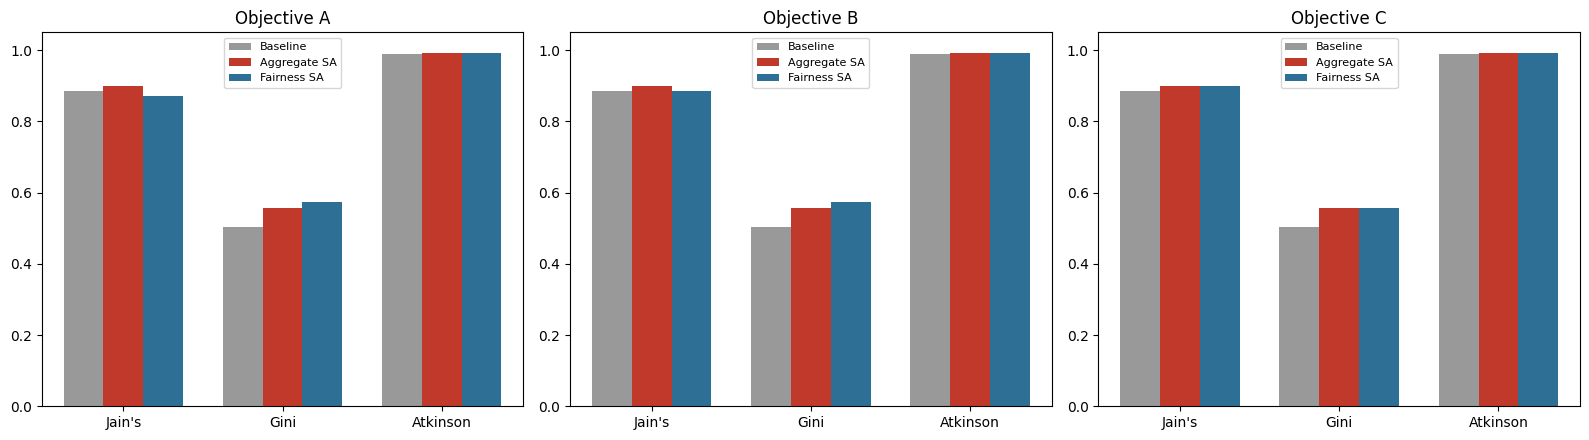

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
metrics = ["jain", "gini", "atkinson"]
labels = ["Jain's", "Gini", "Atkinson"]

for ax, (name, result) in zip(axes, [("Objective A", result_A), ("Objective B", result_B), ("Objective C", result_C)]):
    baseline_vals = [result["baseline"][m] for m in metrics]
    agg_vals = [result["aggregate"][m] for m in metrics]
    fair_vals = [result["fairness"][m] for m in metrics]
    x = range(len(metrics))
    width = 0.25
    ax.bar([i - width for i in x], baseline_vals, width, label="Baseline", color="#999999")
    ax.bar(list(x), agg_vals, width, label="Aggregate SA", color="#C0392B")
    ax.bar([i + width for i in x], fair_vals, width, label="Fairness SA", color="#2E6F95")
    ax.set_xticks(list(x)); ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.05)
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("aggregate_vs_fairness_comparison_v5.png", dpi=150)
plt.show()


## 9. Multi-seed robustness

Runs the fairness-active SA (Objective A) across **10 genuinely scattered seeds**
(`SEEDS` in Section 0: 42, 47, 59, 123, 1000, 7, 88, 256, 4096, 31337), not sequential
0-9, per supervisor instruction.

In [14]:
robustness_rows = []
for seed in SEEDS:
    rng = random.Random(seed)
    best, best_cost, accepted, history = sa_optimise(
        sessions, cost_jain_primary, ROBUSTNESS_ITERATIONS, T0, COOLING, rng)
    r = cost_jain_primary(best)
    robustness_rows.append({
        "seed": seed, "hard": r["hard"], "logical": r["logical"],
        "jain": r["jain"], "gini": r["gini"], "atkinson": r["atkinson"],
        "mean_V": r["math"]["mean"], "sd_V": r["math"]["sd"], "max_V": r["math"]["max"],
        "accepted_moves": accepted,
    })

robustness_df = pd.DataFrame(robustness_rows)
print(robustness_df.to_string(index=False))
print()
summary = robustness_df[["hard", "logical", "jain", "gini", "atkinson", "mean_V", "sd_V"]].agg(["mean", "std"])
print("--- Across-seed summary ---")
print(summary.to_string())
robustness_df.to_csv("seed_robustness_table_v5.csv", index=False)


 seed  hard  logical     jain     gini  atkinson   mean_V     sd_V  max_V  accepted_moves
   42     6       11 0.893295 0.539832  0.991427 0.295202 0.243591    1.0             333
   47     6        3 0.892370 0.538231  0.991408 0.295133 0.244794    1.0             303
   59     4        9 0.896200 0.578978  0.992075 0.312326 0.234033    1.0             328
  123     3       11 0.881590 0.545400  0.990923 0.310166 0.252816    1.0             300
 1000     5       10 0.898049 0.558319  0.991977 0.298214 0.236456    1.0             329
    7     5        9 0.862621 0.564244  0.990548 0.339906 0.263424    1.0             308
   88     4        6 0.895140 0.569041  0.991915 0.309822 0.236222    1.0             290
  256     3       11 0.877445 0.524165  0.990463 0.303563 0.260278    1.0             317
 4096     6       13 0.877167 0.520217  0.990352 0.304083 0.260420    1.0             298
31337     5       11 0.874587 0.504493  0.989973 0.297901 0.265870    1.0             308

--- Acros

## 10. Final schedule and highest-burden tutors

In [15]:
final_sessions = result_A["fairness_best"]

final_schedule_rows = []
for s in sorted(final_sessions, key=lambda s: (s["tutor"], DAY_ORDER.index(s["day"]), s["start"])):
    real_end = s["start"] + s["duration"]
    final_schedule_rows.append({
        "TUTOR_ID": s["tutor"], "COURSE_ID": s["course"], "CLASS_ID": s["class_id"],
        "SECTION": s["section"], "DAY": s["day"],
        "START": f"{s['start']//60:02d}:{s['start']%60:02d}",
        "END_ACTUAL": f"{real_end//60:02d}:{real_end%60:02d}",
        "END_SCHEDULED_BLOCK": f"{session_end(s)//60:02d}:{session_end(s)%60:02d}",
        "ROOM_ID": s["room"], "ROOM_TYPE": room_type_by_id.get(s["room"]), "CAMPUS_ID": s["campus"],
        "MERGED_GROUP_ID": s["merged_group"] or "",
    })

final_schedule_df = pd.DataFrame(final_schedule_rows)
final_schedule_df.to_csv(f"final_schedule_{SEMESTER}_v5.csv", index=False)
print(f"Final schedule written ({len(final_schedule_df)} rows)")
final_schedule_df.head(15)


Final schedule written (556 rows)


,TUTOR_ID,COURSE_ID,CLASS_ID,SECTION,DAY,START,END_ACTUAL,END_SCHEDULED_BLOCK,ROOM_ID,ROOM_TYPE,CAMPUS_ID,MERGED_GROUP_ID
0,T001,IT7003,21263,013,Sunday,14:00,15:50,16:00,25.328,Lab,B,
1,T001,IT7003,21269,014,Monday,10:00,11:50,12:00,19.108,General,A,MERGE157
2,T001,IT7003,21271,015,Monday,10:00,11:50,12:00,19.108,General,A,MERGE157
3,T001,IT7003,21271,015,Tuesday,08:00,09:50,10:00,25.118,Lab,B,
4,T001,IT7003,21269,014,Tuesday,14:00,15:50,16:00,20.209,Lab,B,
5,T001,IT7003,21271,015,Wednesday,14:00,15:50,16:00,20.209,Lab,B,
6,T001,IT7003,21263,013,Wednesday,16:00,17:50,18:00,25.328,Lab,B,
7,T001,IT7003,21269,014,Thursday,12:00,13:50,14:00,25.323,Lab,B,
8,T002,IT7008,21205,001,Sunday,14:00,15:50,16:00,20.262,Lab,B,
9,T002,IT7008,21205,001,Monday,14:00,15:50,16:00,25.137,Lab,B,


In [16]:
final_V = result_A["fairness"]["V"]
baseline_V = result_A["baseline"]["V"]
highest_burden = sorted(final_V, key=lambda t: final_V[t], reverse=True)[:10]

print(f"{'TUTOR':8s} {'V before':>10s} {'V after':>10s} {'active profiles (weight)':>40s}")
for t in highest_burden:
    before = baseline_V.get(t, 0.0)
    after = final_V.get(t, 0.0)
    weights = tutor_weights.get(t, {})
    active = ", ".join(f"{p}={w:.2f}" for p, w in weights.items() if w > 0) or "none (P8)"
    print(f"{t:8s} {before:10.3f} {after:10.3f} {active:>40s}")


TUTOR      V before    V after                 active profiles (weight)
T042          1.000      1.000                                  P4=1.00
T064          1.000      1.000                                  P3=1.00
T017          1.000      1.000                                  P3=1.00
T002          0.222      0.778                         P3=0.67, P5=0.33
T014          0.667      0.778                         P3=0.67, P7=0.33
T075          0.667      0.778                         P3=0.67, P7=0.33
T046          0.333      0.722                         P3=0.67, P7=0.33
T056          0.667      0.667                         P3=0.67, P7=0.33
T054          0.167      0.667                         P1=0.67, P6=0.33
T089          0.500      0.667                                  P1=1.00


## 11. Notes for next steps

- Iteration counts (Section 0) are lower than v4's defaults, deliberately, to keep three
  full objectives' worth of runs practical in one sitting. Raise them once you're past
  correctness-checking.
- L3's citation set is in `Thesis_Writing_Notes.md` / `Demo_Prep_Notes.md`.
- Objective C is additive, Objective B is untouched, delete whichever isn't needed for
  your actual research once you've compared results.
- `cost_aggregate_only` now includes `mean(V)`, so "aggregate" in the three-stage
  comparison is no longer purely hard+logical, keep that in mind when writing up what
  the comparison demonstrates.


## 12. Individual tutor checker — built in

Shows a specific tutor's profile, and for every profile with nonzero weight, the exact
raw count, ceiling, normalized value, and weighted contribution, before vs. after SA.
Replaces the ad-hoc version from before with one that matches the new normalized model.

In [17]:
TUTOR_ID = "T057"  # change this to whichever tutor you want to check
COMPARE_AFTER = result_A["fairness_best"]  # swap to result_B/result_C or *_aggregate_best as needed

def explain_violations(label, sessions_state):
    r = cost_jain_primary(sessions_state)
    detail = r["V_detail"].get(TUTOR_ID)
    print(f"--- {label} ---")
    if detail is None:
        print(f"{TUTOR_ID} not found in this schedule state.\n")
        return

    active = [(p, d) for p, d in detail.items() if d["weight"] > 0]
    active.sort(key=lambda pd: -pd[1]["weight"])

    if not active or active[0][0] == "P8":
        print("Profile: P8, no preference. V(t) = 0 by construction.\n")
        return

    for profile, d in active:
        contribution = d["weight"] * d["normalized"]
        print(f"{profile}  weight={d['weight']:.3f}  raw={d['raw']}  ceiling={d['ceiling']}  "
              f"normalized={d['normalized']:.3f}  weighted contribution={contribution:.3f}")

    print(f"V({TUTOR_ID}) = {r['V'].get(TUTOR_ID, 0):.3f}\n")

explain_violations("BEFORE (baseline)", sessions)
explain_violations("AFTER (Objective A, fairness SA)", COMPARE_AFTER)


--- BEFORE (baseline) ---
P1  weight=0.500  raw=4  ceiling=9  normalized=0.444  weighted contribution=0.222
P6  weight=0.333  raw=0  ceiling=6  normalized=0.000  weighted contribution=0.000
P3  weight=0.167  raw=2  ceiling=2  normalized=1.000  weighted contribution=0.167
V(T057) = 0.389

--- AFTER (Objective A, fairness SA) ---
P1  weight=0.500  raw=3  ceiling=9  normalized=0.333  weighted contribution=0.167
P6  weight=0.333  raw=1  ceiling=6  normalized=0.167  weighted contribution=0.056
P3  weight=0.167  raw=2  ceiling=2  normalized=1.000  weighted contribution=0.167
V(T057) = 0.389

